# Spin Waves with Nonlocal Damping in `LambdaLLG`

This notebook reproduces, at the level of the effective `LambdaLLG` model, some of the spin-wave damping trends discussed in Felipe Reyes-Osorio and Branislav K. Nikolić, [*Nonlocal damping of spin waves in a magnetic insulator induced by normal, heavy, or altermagnetic metallic overlayer: A Schwinger-Keldysh field theory approach*](https://doi.org/10.1103/PhysRevB.110.214432), *Phys. Rev. B* **110**, 214432 (2024).

The paper shows that replacing local Gilbert damping by a finite-range nonlocal damping tensor leads to wave-vector-dependent spin-wave damping. Here we focus on a simple normal-metal-style kernel, evolve frozen-magnon states with different wavevectors, and fit their time traces to extract the damping-to-frequency ratio.

In [1]:
# Activate the package environment in the repository root.
using Pkg; Pkg.activate("../")

  Activating project at `/mnt/graphene/home/freyes/libs/LambdaLLG.jl`


In [2]:
# Load the 1D LLG tools and plotting backend used throughout the notebook.
using LambdaLLG

import PyPlot as plt

## 1. One-Dimensional Spin Waves

We start in 1D because it is the clearest setting for seeing how the nonlocal kernel modifies damping. The calculation proceeds in three steps:

1. Define a 1D `LLGParams1D` model and a finite-range damping tensor `Λtens`.
2. Build frozen-magnon initial states with phase winding set by the wavevector `k`, then evolve each case in time.
3. Fit the transverse motion at a representative site to a damped cosine and compare the extracted damping rate with the precession frequency.

In [5]:
# Load the helper packages used in the analysis cells below.
using Bessels: besselj0
using LsqFit

using HDF5
using Printf

In [3]:
# Magnetic parameters for the 1D frozen-magnon example.
Nx = 100

J = 1.0
K = (0.0, 0.0, 0.5)
αG = 0.05
B_ext = (0.0, 0.0, 0.0)

# Build the 1D parameter object.
par = LLGParams1D(
    Nx,                    # Number of sites
    J,                     # Heisenberg exchange
    K,                     # Anisotropy vector
    B_ext,                 # External field
    αG                     # Gilbert damping
    );

In [6]:
# Build a diagonal 1D nonlocal damping kernel with finite real-space cutoff.
cutoff = 50
Λtens = zeros(3,3,2*cutoff+1)

for (i,dx) in enumerate(-cutoff:cutoff)
    for c in 1:3
        Λtens[c,c,i] = 0.01 * besselj0(0.5*dx)^2
    end
end

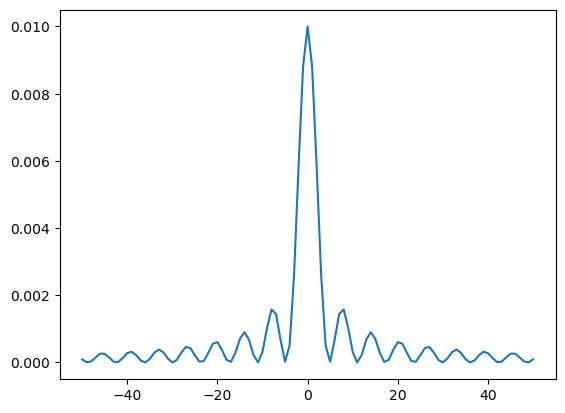

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff2a555de80>

In [7]:
# Visualize the 1D kernel profile used in the simulation.
plt.plot(-cutoff:cutoff, Λtens[1,1,:])

In [8]:
# Attach the nonlocal damping kernel to the 1D parameter object.
par.ker_dx = -cutoff:cutoff
par.Λtens = Λtens;

### Evolve Frozen Magnons

In [9]:
# Launch small-angle 1D spin waves with different wavevectors and evolve each case.
ks = 0:0.1:1.5
tspan = (0.0, 100.)

results = []

for (i,k) in enumerate(ks)
    if i%4==0 println("Current k is the $i-th") end
    angles = [(0.3, k*i) for i=1:par.Nx]  # tuples are (θ, ϕ)

    initial_state = stack([[sin(th)*cos(ph), sin(th)*sin(ph), cos(th)] for (th, ph) in angles])
    s0 = reshape(initial_state, 3*par.Nx)
    
    tspan = (0.0, 100.)

    sol = evolve1D(s0, tspan, par)
    
    push!(results, format_results(sol))
end

Current k is the 4-th
Current k is the 8-th
Current k is the 12-th
Current k is the 16-th


In [10]:
# Fit the transverse component at one site to extract damping and frequency.
sit = 50

model(x, p) = sin(0.3) .* exp.(-x .* p[1]) .* cos.(p[2] .* x .+ p[3])

fit_params = []

for (i,res) in enumerate(results)
    ts = res[:,1]
    
    w_guess = par.J*ks[i]^2 + par.K[3]
    damp_guess = w_guess * par.αG

    fit = curve_fit(model, ts, res[:, sit*3-1], [damp_guess, w_guess, 0])
    
    push!(fit_params, fit.param)
   
    # Uncomment to inspect the quality of the fit for a selected wavevector.
#
#     plt.figure(figsize=(2,2))
#     plt.plot(ts, res[:, sit*3-1])
#     plt.plot(ts, model(ts, fit.param), "--")
    
end

fit_params = hcat(fit_params...)

3×16 Matrix{Float64}:
  0.0596272   0.04639    0.0457786  …  0.0987736  0.104402   0.116951
  0.486603    0.497922  -0.528143      1.92763    2.1234     2.32155
 -0.0479251  -1.31951    2.60899       2.10028    0.813658  -0.500576

### 1D Damping-to-Frequency Ratio

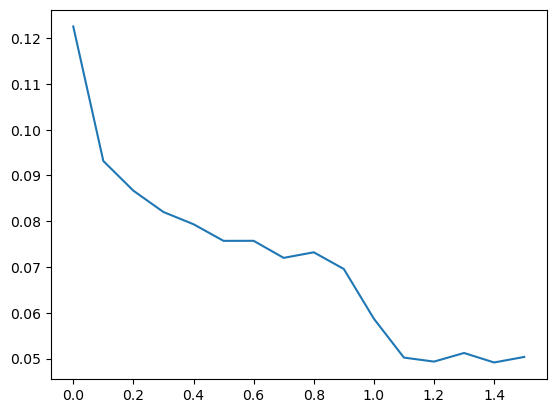

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff2a4f593a0>

In [11]:
# Plot the fitted damping-to-frequency ratio as a function of wavevector.
plt.plot(ks, fit_params[1,:] ./ abs.(fit_params[2,:]))

## 2. Two-Dimensional Extension

The second half of the notebook repeats the same logic in 2D. We build a radially symmetric nonlocal kernel, launch plane-wave textures on a square lattice, save one representative lattice-site trace for each wavevector, and refit those traces with the same damped-cosine model used in 1D. This provides a direct check that the wave-vector-dependent damping trend survives beyond the 1D toy problem.

In [12]:
# Reuse the same magnetic parameters on a 2D grid.
Nx = 100
Ny = 100

par_2d = LLGParams2D(
    Nx,                 # Number of sites along x
    Ny,                 # Number of sites along y
    1.0,                # NN Heisenberg exchange
    (0.,0.,0.5),        # Anisotropy vector
    (0.0,0.0,0.0),      # External field
    0.05                 # Gilbert damping
    );

In [21]:
# Build a radially symmetric 2D damping kernel and attach it to the model.
cutoff = 20
Λtens = zeros(3,3,2*cutoff+1,2*cutoff+1)

for (i,dx) in enumerate(-cutoff:cutoff)
    for (j,dy) in enumerate(-cutoff:cutoff)
        r = hypot(dx, dy)
        for c in 1:3
            Λtens[c,c,i,j] = 0.005 * besselj0(0.5*r)^2
        end
    end
end

par_2d.ker_dx = -cutoff:cutoff
par_2d.ker_dy = -cutoff:cutoff
par_2d.Λtens = Λtens;

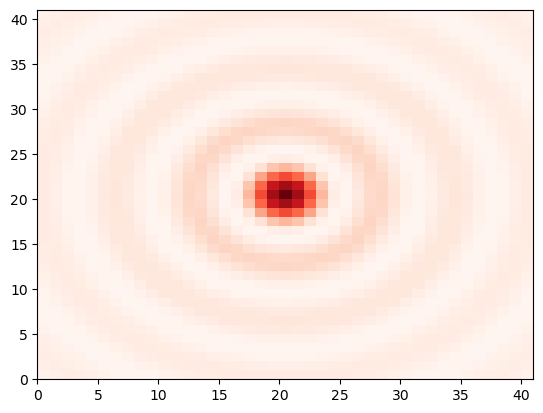

PyObject <matplotlib.collections.QuadMesh object at 0x7ff2df484550>

In [22]:
# Inspect the 2D kernel in real space.
plt.pcolormesh(Λtens[1,1,:,:], cmap="Reds")

### Evolve, Save, and Refit 2D Frozen Magnons

In [23]:
# Evolve 2D plane-wave initial states and collect the formatted time traces.
ks = 0:0.1:1.5
angle = 0.0
tspan = (0.0, 100.)

results = []

for (i,k) in enumerate(ks)
    kx = k*cos(angle)
    ky = k*sin(angle)
    
    if i%1==0 
        println("Current k is the $i-th"); flush(stdout) 
    end
    
    angles = [(0.3, kx*i + ky*j) for i=1:par_2d.Nx, j=1:par_2d.Ny]  # tuples are (θ, ϕ)

    initial_state = stack([[sin(th)*cos(ph), sin(th)*sin(ph), cos(th)] for (th, ph) in angles])
    s0 = reshape(initial_state, 3*par_2d.Nx*par_2d.Ny)
    
    println("Ready to evolve")    
    @elapsed sol = evolve2D(s0, tspan, par_2d; verbose=true)
    flush(stdout)
    
    push!(results, format_results(sol))
end

Current k is the 1-th
Ready to evolve
time is 0.04296207010262052
time is 0.17833268342095965
time is 0.36920677621108644
time is 0.5917485877200017
time is 0.8606876142981419
time is 1.1684662044311138
time is 1.5138293720913274
time is 1.8888922750593315
time is 2.2952311593102688
time is 2.7254350668605163
time is 3.1781432295289074
time is 3.650161029159886
time is 4.1382025246207474
time is 4.64046809186053
time is 5.153804354827813
time is 5.650254228263144
time is 6.085886683681627
time is 6.471584321705651
time is 6.827293251926569
time is 7.160452369091587
time is 7.478418695779384
time is 7.7858973144152674
time is 8.084981206209955
time is 8.37682873310899
time is 8.663606212778861
time is 8.94734948280554
time is 9.228799337487121
time is 9.508824559499145
time is 9.788777944653209
time is 10.068334810658122
time is 10.347161989187237
time is 10.62711879668133
time is 10.908919824927032
time is 11.191393880712846
time is 11.474742058907761
time is 11.759709010414639
time is

time is 94.18883051757825
time is 94.48545836845832
time is 94.78207995727237
time is 95.07869520050991
time is 95.37530403049084
time is 95.67190651064811
time is 95.96850248288757
time is 96.26509193831227
time is 96.56167505337203
time is 96.85825199320188
time is 97.15482259292999
time is 97.45138682783026
time is 97.74794478618522
time is 98.0444965178489
time is 98.34104193706942
time is 98.63758106432157
time is 98.93411394493783
time is 99.23064055871026
time is 99.52716065718741
time is 99.82367447327523
time is 100.0
Current k is the 2-th
Ready to evolve
time is 0.04285404298598435
time is 0.13775923487677727
time is 0.2581127491495195
time is 0.4033402373747019
time is 0.5722964129545672
time is 0.7636136519671135
time is 0.9757635859780764
time is 1.2064498905625554
time is 1.4533381112662707
time is 1.713871941756072
time is 1.985527028132234
time is 2.26854757541205
time is 2.560455792861755
time is 2.8589718315753334
time is 3.1661043623168945
time is 3.4787701950266623


time is 88.02723244672671
time is 88.32335853274121
time is 88.61947866065465
time is 88.91559271323597
time is 89.21170065901745
time is 89.50780260418978
time is 89.80389870909463
time is 90.09998912277939
time is 90.39607381601567
time is 90.69215266254844
time is 90.9882256354165
time is 91.28429291073714
time is 91.58035452020758
time is 91.87641044814082
time is 92.17246069690178
time is 92.46850520116809
time is 92.76454398135733
time is 93.06057706014172
time is 93.35660464068094
time is 93.65262687197554
time is 93.94864361424527
time is 94.24465480216786
time is 94.5406604313364
time is 94.83666058758038
time is 95.13265523039472
time is 95.42864442755672
time is 95.72462829646642
time is 96.02060684849664
time is 96.3165800205825
time is 96.61254781282182
time is 96.90851040576197
time is 97.20446781077044
time is 97.50041992192656
time is 97.7963667370699
time is 98.09230830140447
time is 98.3882446398327
time is 98.68417573214809
time is 98.98010173631769
time is 99.276022

time is 81.42641100450733
time is 81.72268007255816
time is 82.01894412114876
time is 82.3152032135892
time is 82.61145550982704
time is 82.90770039141769
time is 83.20393991534073
time is 83.50017516537444
time is 83.79640466956921
time is 84.09262796749083
time is 84.38884756292204
time is 84.68506401577248
time is 84.98127576609863
time is 85.27748201031294
time is 85.57368348897185
time is 85.86987891994534
time is 86.16606596929573
time is 86.46224598036781
time is 86.75842357840187
time is 87.05459895300766
time is 87.35076925103421
time is 87.64693441163766
time is 87.9430954890005
time is 88.23925134784652
time is 88.53540053699288
time is 88.83154433632706
time is 89.1276842716571
time is 89.42381866385253
time is 89.71994617920976
time is 90.01606966151797
time is 90.31219092080569
time is 90.60830828701627
time is 90.90442035873697
time is 91.20052799363644
time is 91.49663081039766
time is 91.79272628165994
time is 92.08881441441396
time is 92.38489953462803
time is 92.6809

time is 74.09273651529878
time is 74.38897932551039
time is 74.68521700156288
time is 74.98144849373065
time is 75.27767407758834
time is 75.57389241226714
time is 75.87010120437495
time is 76.16630381779557
time is 76.46250362294558
time is 76.75870091103717
time is 77.05489409286
time is 77.3510823084161
time is 77.64726541107188
time is 77.9434413287622
time is 78.23960798962405
time is 78.5357674073168
time is 78.83192445954333
time is 79.12807792295182
time is 79.42422647493758
time is 79.7203709687387
time is 80.01651157819484
time is 80.31264619310008
time is 80.60877411170708
time is 80.90489671311073
time is 81.20101347834024
time is 81.49712290001628
time is 81.79322749002644
time is 82.08932976012616
time is 82.38542911455029
time is 82.68152360807774
time is 82.97761318889742
time is 83.27369803762275
time is 83.56977590458955
time is 83.86584476824562
time is 84.16190851886525
time is 84.45797127440544
time is 84.754030458046
time is 85.05008516954288
time is 85.3461360204

...

time is 69.37103109764675
time is 69.79266664563144
time is 70.19806175219746
time is 70.58147280979654
time is 70.94471982424925
time is 71.29105865868439
time is 71.62357738700129
time is 71.94497830518804
time is 72.25750193717994
time is 72.56303540660379
time is 72.86312706417306
time is 73.15903404498931
time is 73.45180098268935
time is 73.74227542175772
time is 74.0311331540897
time is 74.31893546717323
time is 74.60613087031382
time is 74.89307056509027
time is 75.18003411593128
time is 75.46724080101721
time is 75.75484359415081
time is 76.04295930285684
time is 76.3316734562927
time is 76.62102731295569
time is 76.91104176848825
time is 77.20172969037407
time is 77.49306970183358
time is 77.78503329558876
time is 78.07759725006703
time is 78.37071098497182
time is 78.66432658172664
time is 78.9584072775807
time is 79.2528959860834
time is 79.54774272213922
time is 79.84291044246648
time is 80.13834874241432
time is 80.4340143311159
time is 80.72987667609893
time is 81.025898

time is 49.26471817115004
time is 49.682168032309455
time is 50.10302981945672
time is 50.527305587173274
time is 50.955103201003276
time is 51.386431832576164
time is 51.82137221748834
time is 52.259917203431016
time is 52.70196916966675
time is 53.146697323731104
time is 53.589976909088584
time is 54.018366770868965
time is 54.418052024064764
time is 54.79101609867387
time is 55.14302230596449
time is 55.4783477368191
time is 55.80059315827951
time is 56.11262255057035
time is 56.416729163279925
time is 56.714766521132574
time is 57.00822682834733
time is 57.29830684290721
time is 57.58597242888238
time is 57.87200284234375
time is 58.15701667904325
time is 58.4415051115812
time is 58.725871542004384
time is 59.01041411544078
time is 59.29536195538283
time is 59.58089296431029
time is 59.86712653403473
time is 60.15414009964067
time is 60.441984365831885
time is 60.730675049989145
time is 61.0202078012348
time is 61.310560178552784
time is 61.60169709555231
time is 61.89357127712171


time is 24.685849242450537
time is 24.909693781990654
time is 25.134521140347793
time is 25.360696416885542
time is 25.587600077160445
time is 25.815322147174214
time is 26.044499806595667
time is 26.274512644088635
time is 26.505272432800403
time is 26.737502170740576
time is 26.970684558084763
time is 27.204618987137597
time is 27.439973328810122
time is 27.67639569790101
time is 27.913606328707548
time is 28.152183636243816
time is 28.391914652976993
time is 28.632476954690265
time is 28.874387349778793
time is 29.117498908396417
time is 29.361500350950053
time is 29.606853548202558
time is 29.85342921950846
time is 30.10095530765028
time is 30.349865883276287
time is 30.599999401652667
time is 30.851158224592023
time is 31.103738624650187
time is 31.357536161047193
time is 31.612428214703677
time is 31.868800822065165
time is 32.12636254147467
time is 32.385124162347694
time is 32.64539060122117
time is 32.906841107517195
time is 33.16961728040794
time is 33.43388064413557
time is 

time is 8.593831959874331
time is 8.744847614655848
time is 8.896457918934894
time is 9.048725789004196
time is 9.20139942522226
time is 9.35423054392764
time is 9.507359632116792
time is 9.661327010975851
time is 9.81574490092494
time is 9.97045469762337
time is 10.125266950035082
time is 10.280926683114695
time is 10.437152597920864
time is 10.59374794044394
time is 10.750463425666203
time is 10.907817752501575
time is 11.065921638827437
time is 11.224422927450293
time is 11.383117122938625
time is 11.542240793581195
time is 11.702256839909664
time is 11.862721123820904
time is 12.023442555991224
time is 12.184448393323516
time is 12.346423196318579
time is 12.508896259542391
time is 12.671687022454204
time is 12.834718173603735
time is 12.998695702393379
time is 13.163252001101876
time is 13.328160141045956
time is 13.493282569790585
time is 13.659341553615347
time is 13.826038506740137
time is 13.993114220503669
time is 14.160419860618855
time is 14.328642181137702
time is 14.49755

time is 91.28925632255718
time is 91.58536912591106
time is 91.88147803178597
time is 92.17758292739666
time is 92.47368385116215
time is 92.7697806880459
time is 93.06587372244184
time is 93.36196269488734
time is 93.65804757384716
time is 93.95412848800183
time is 94.25020535165629
time is 94.54627814004492
time is 94.84234694122576
time is 95.13841164694364
time is 95.4344722076152
time is 95.7305287067846
time is 96.02658128214335
time is 96.3226299427676
time is 96.61867458266357
time is 96.9147151071244
time is 97.21075173506027
time is 97.50678438529894
time is 97.80281299020942
time is 98.09883763558
time is 98.39485839365791
time is 98.69087529382222
time is 98.98688825039348
time is 99.28289735140852
time is 99.57890257661356
time is 99.87490401855273
time is 100.0


In [24]:
# Save the time trace of one representative 2D lattice site for each wavevector.
η = 0.005
sit_x = 50
sit_y = 50

lin_sit = par_2d.Nx * (sit_y - 1) + sit_x

for (kidx,k) in enumerate(ks)
    wavecname = @sprintf "wavec_%.2f_" k
    llgparsname = @sprintf "anis%.2f_gil%.2f" par_2d.K[3] par_2d.αG
    kerfilename = @sprintf "NORMAL_METAL_eta%.3f" η
    filename = "data/frozen_magnon_" * wavecname * llgparsname * kerfilename * ".h5"

    h5open(filename, "w") do f
        write(f, "data", copy(results[kidx][:,[1,lin_sit*3-1]]))
    end
end

In [25]:
# Reload the saved traces so the fitting step can be repeated without rerunning dynamics.
η = 0.005

data = []
all_ts = []

for k in ks
    wavecname = @sprintf "wavec_%.2f_" k
    llgparsname = @sprintf "anis%.2f_gil%.2f" par_2d.K[3] par_2d.αG
    kerfilename = @sprintf "NORMAL_METAL_eta%.3f" η
    filename = "data/frozen_magnon_"*wavecname*llgparsname*kerfilename*".h5"

    f = h5open(filename, "r")
    ts = read(f, "data")[:,1]
    xdata = read(f, "data")[:,2]
    close(f)

    push!(data, xdata)
    push!(all_ts, ts)
end

In [26]:
# Fit the saved 2D traces with the same damped-cosine model used in 1D.
fit_params2d = []

sit_x = 50
sit_y = 50
lin_sit = par_2d.Nx * (sit_y - 1) + sit_x

for (i,dat) in enumerate(data)
    
    w_guess = par_2d.J*ks[i]^2 + par_2d.K[3]
    damp_guess = w_guess * par_2d.αG

    fit = curve_fit(model, all_ts[i], dat, [damp_guess, w_guess, 0])
    
    push!(fit_params2d, fit.param)
   
    # Uncomment to inspect the quality of the fit for a selected 2D wavevector.

#     plt.figure(figsize=(2,2))
#     plt.plot(res[:,1], res[:,lin_sit*3-1])
#     plt.plot(res[:,1], model(res[:,1], fit.param), "--")
    
end

fit_params2d = hcat(fit_params2d...)

3×16 Matrix{Float64}:
  0.183266    0.146543  0.059325  0.0634991  …  0.11576  0.100502   0.101663
  0.366539    0.443142  0.526216  0.57337       1.92803  2.123      2.31218
 -0.0354829  -1.28803   3.67469   2.38592       2.10099  0.805647  -0.490647

### 2D Damping-to-Frequency Ratio

The same qualitative trend persists in 2D.

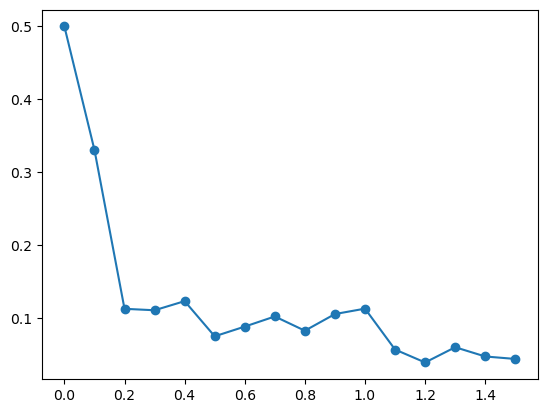

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff2df2f56a0>

In [27]:
# Compare the fitted 2D damping-to-frequency ratio across wavevectors.
plt.plot(ks, fit_params2d[1,:] ./ abs.(fit_params2d[2,:]), "o-")

## Summary

This notebook builds simple 1D and 2D frozen-magnon states, adds a finite-range nonlocal damping kernel, and fits the resulting time traces to extract how damping scales relative to the precession frequency. In that sense, it serves as a compact reproduction of the paper's central qualitative message: nonlocal damping produces wave-vector-dependent spin-wave decay, even in otherwise simple effective LLG dynamics.